In [1]:
import numpy as np
import pandas as pd
df = pd.read_csv("diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [2]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

array([[<Axes: title={'center': 'Pregnancies'}>,
        <Axes: title={'center': 'Glucose'}>,
        <Axes: title={'center': 'BloodPressure'}>],
       [<Axes: title={'center': 'SkinThickness'}>,
        <Axes: title={'center': 'Insulin'}>,
        <Axes: title={'center': 'BMI'}>],
       [<Axes: title={'center': 'DiabetesPedigreeFunction'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Outcome'}>]], dtype=object)

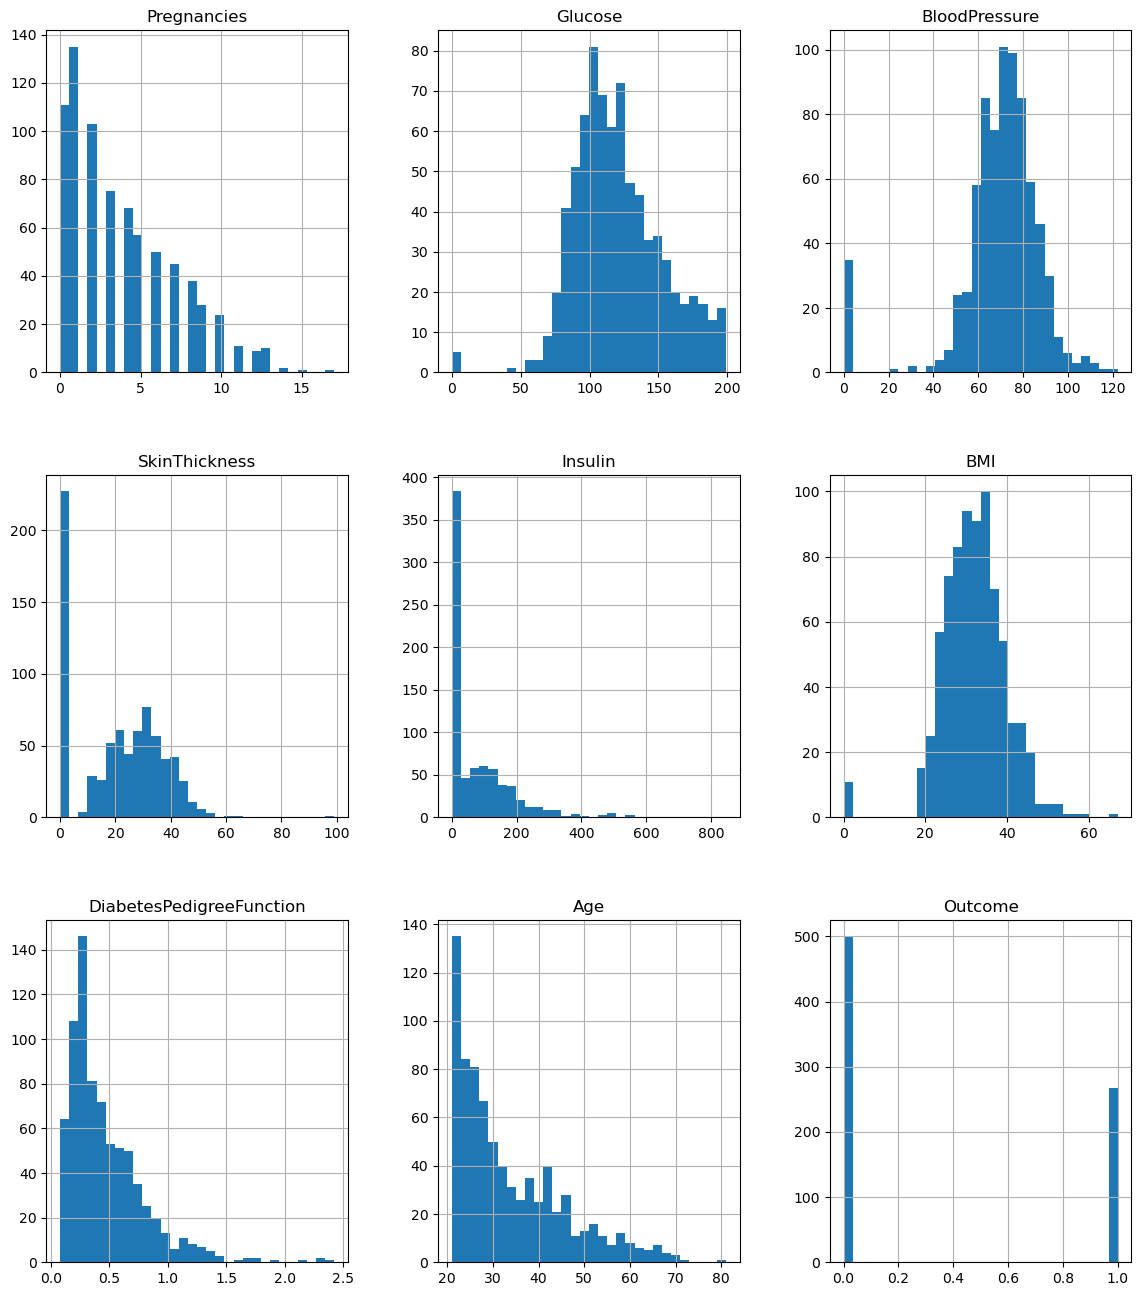

In [3]:
df.hist(figsize =(14,16),bins=30)

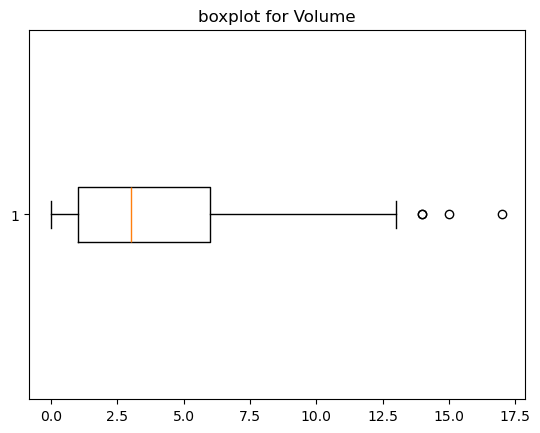

In [4]:
import matplotlib.pyplot as plt
plt.boxplot(df["Pregnancies"],vert=False)
plt.title("boxplot for Volume")
plt.show()

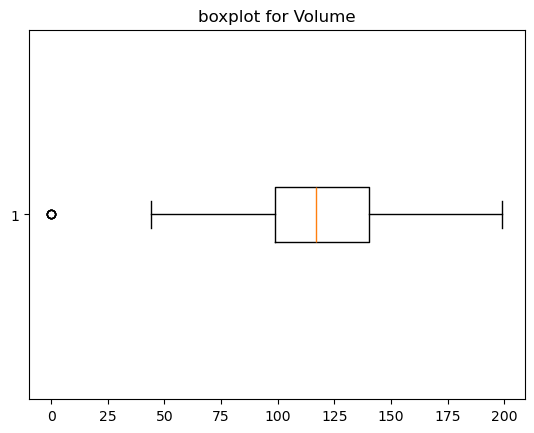

In [5]:
import matplotlib.pyplot as plt
plt.boxplot(df["Glucose"],vert=False)
plt.title("boxplot for Volume")
plt.show()

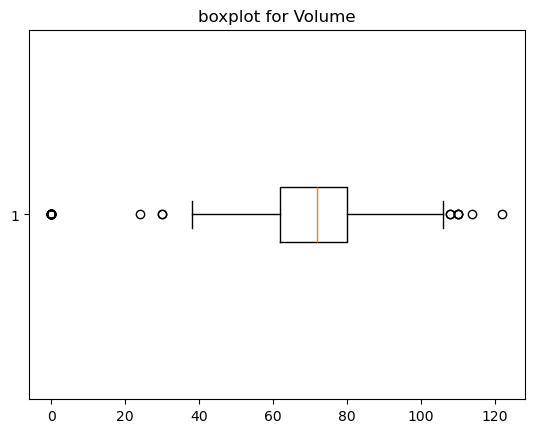

In [6]:
import matplotlib.pyplot as plt
plt.boxplot(df["BloodPressure"],vert=False)
plt.title("boxplot for Volume")
plt.show()

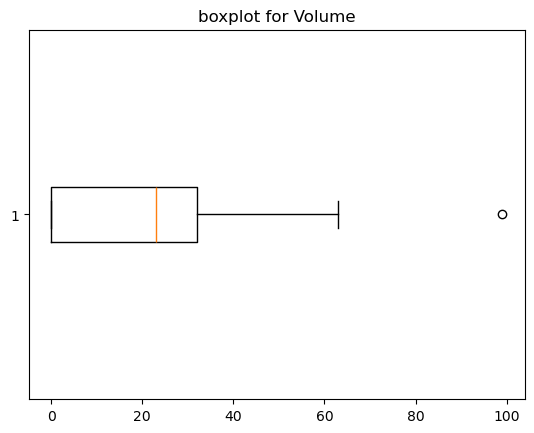

In [7]:
import matplotlib.pyplot as plt
plt.boxplot(df["SkinThickness"],vert=False)
plt.title("boxplot for Volume")
plt.show()

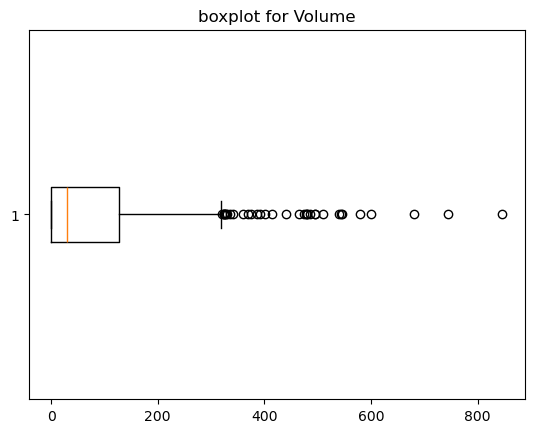

In [8]:
import matplotlib.pyplot as plt
plt.boxplot(df["Insulin"],vert=False)
plt.title("boxplot for Volume")
plt.show()

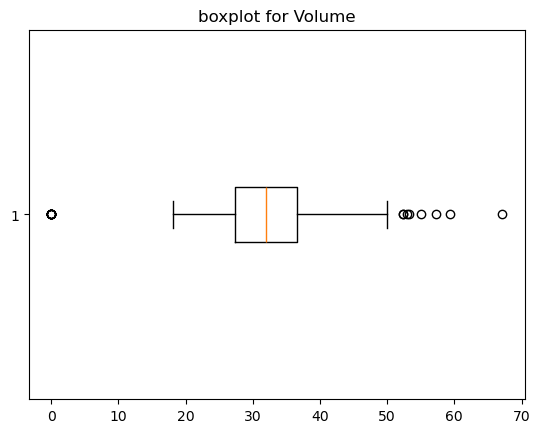

In [9]:
import matplotlib.pyplot as plt
plt.boxplot(df["BMI"],vert=False)
plt.title("boxplot for Volume")
plt.show()

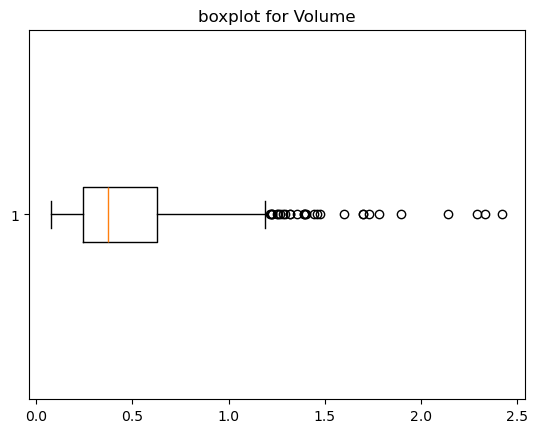

In [10]:
import matplotlib.pyplot as plt
plt.boxplot(df["DiabetesPedigreeFunction"],vert=False)
plt.title("boxplot for Volume")
plt.show()

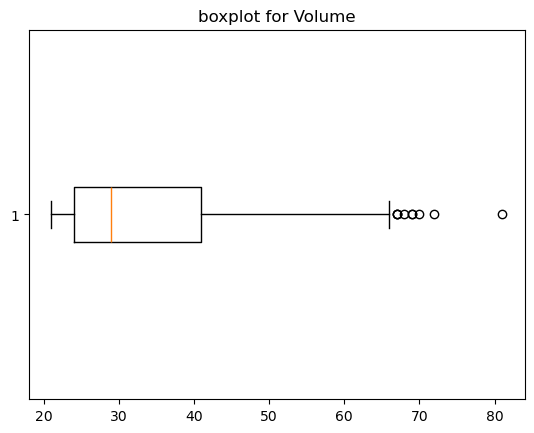

In [11]:
import matplotlib.pyplot as plt
plt.boxplot(df["Age"],vert=False)
plt.title("boxplot for Volume")
plt.show()

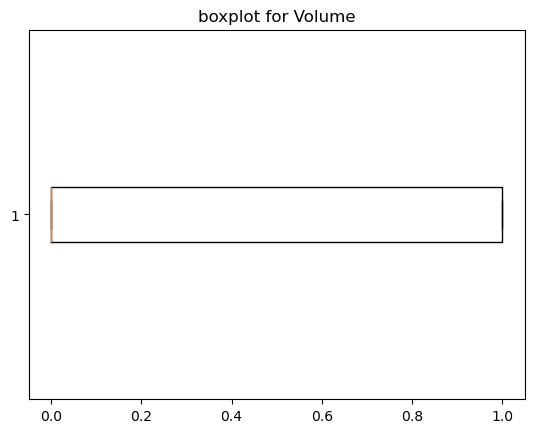

In [12]:
import matplotlib.pyplot as plt
plt.boxplot(df["Outcome"],vert=False)
plt.title("boxplot for Volume")
plt.show()

Text(0.5, 1.0, 'Relationship between Age and Insulin by Outcome')

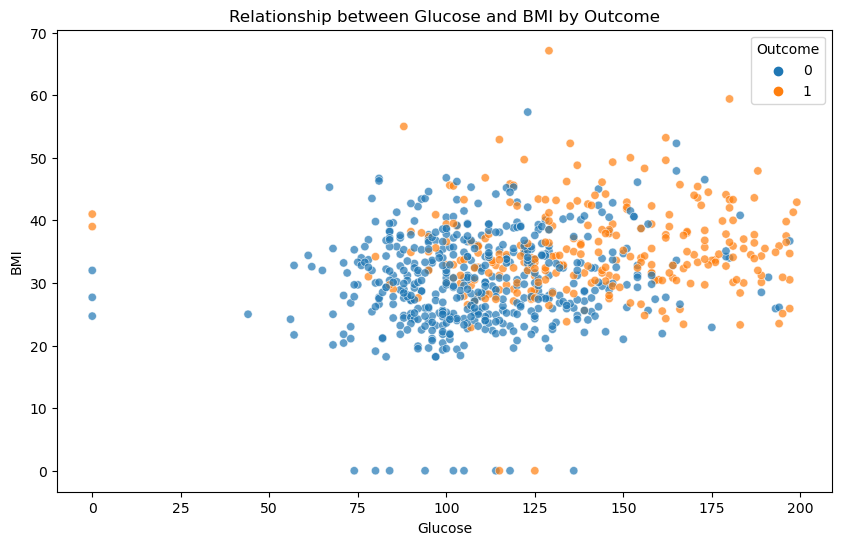

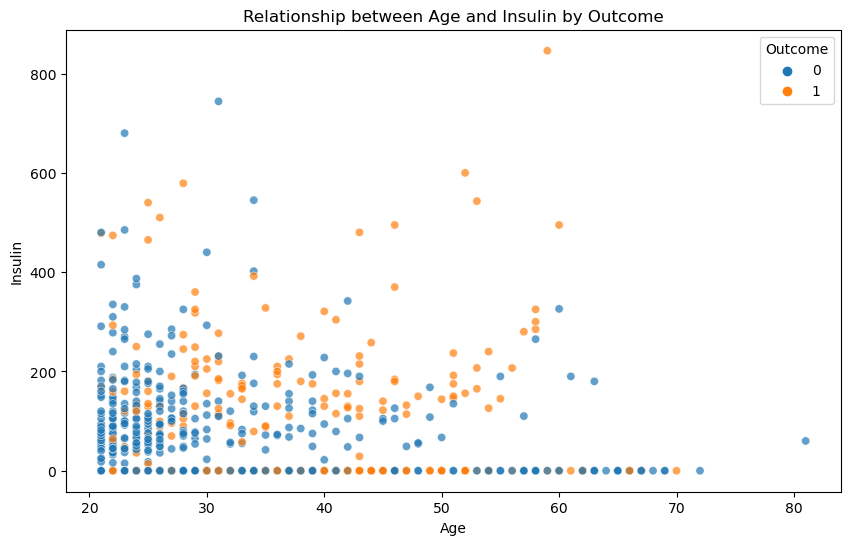

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Glucose', y='BMI', hue='Outcome', alpha=0.7)
plt.title('Relationship between Glucose and BMI by Outcome')
plt.savefig('scatter_glucose_bmi.png')
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='Insulin', hue='Outcome', alpha=0.7)
plt.title('Relationship between Age and Insulin by Outcome')

               Model  Accuracy  Precision    Recall  F1-Score
0      Random Forest  0.746753   0.637931  0.672727  0.654867
1  Gradient Boosting  0.759740   0.655172  0.690909  0.672566


<Figure size 640x480 with 0 Axes>

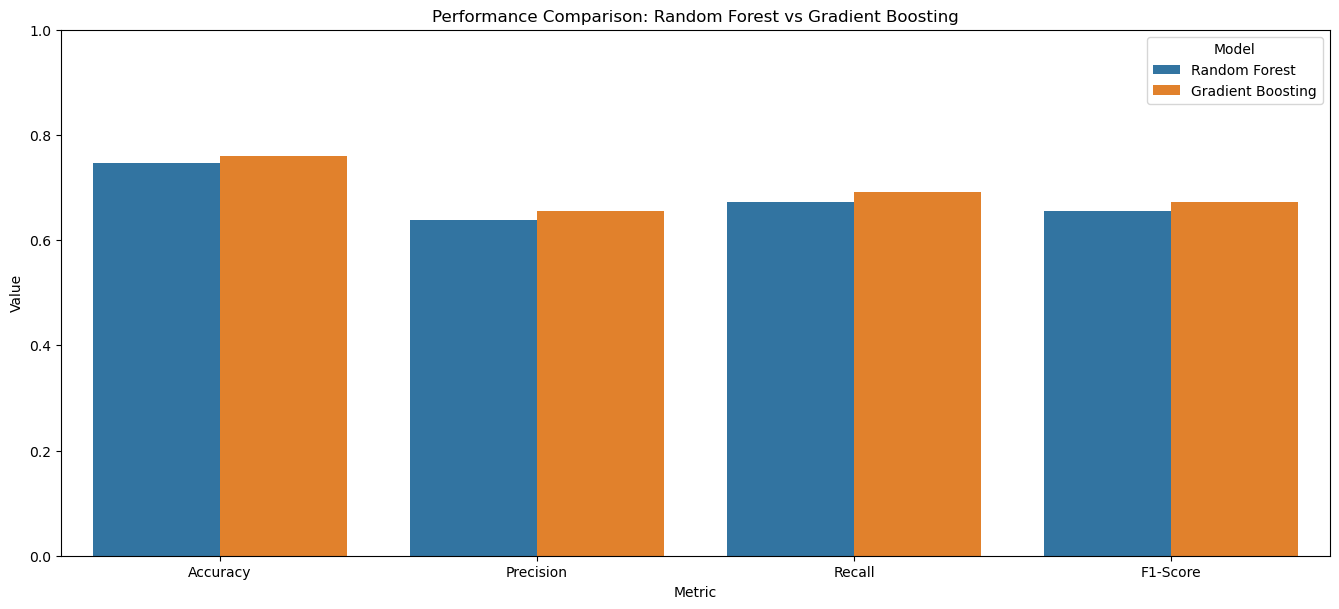

In [27]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Preprocessing: Impute 0s with median (except for Pregnancies and Outcome)
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols_with_zeros:
    df[col] = df[col].replace(0, pd.NA)
    df[col] = df[col].fillna(df[col].median())

# Split
X = df.drop('Outcome', axis=1)
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model 1: Random Forest
rf = RandomForestClassifier(random_state=42)
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10],
    'min_samples_split': [2, 5]
}
grid_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring='accuracy')
grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_

# Model 2: Gradient Boosting
gb = GradientBoostingClassifier(random_state=42)
param_grid_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5]
}
grid_gb = GridSearchCV(gb, param_grid_gb, cv=5, scoring='accuracy')
grid_gb.fit(X_train, y_train)
best_gb = grid_gb.best_estimator_

# Evaluate
def evaluate(model, name):
    y_pred = model.predict(X_test)
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    }

rf_eval = evaluate(best_rf, 'Random Forest')
gb_eval = evaluate(best_gb, 'Gradient Boosting')

results_df = pd.DataFrame([rf_eval, gb_eval])

# Visualizing feature importance for comparison
plt.clf()
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# RF Importances
importances_rf = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values()
importances_rf.plot(kind='barh', ax=axes[0], color='skyblue')
axes[0].set_title('Random Forest Feature Importance')

# GB Importances
importances_gb = pd.Series(best_gb.feature_importances_, index=X.columns).sort_values()
importances_gb.plot(kind='barh', ax=axes[1], color='salmon')
axes[1].set_title('Gradient Boosting Feature Importance')

plt.tight_layout()
plt.savefig('feature_importances_comparison.png')

# Model Comparison Plot
plt.clf()
results_melted = results_df.melt(id_vars='Model', var_name='Metric', value_name='Value')
sns.barplot(x='Metric', y='Value', hue='Model', data=results_melted)
plt.title('Performance Comparison: Random Forest vs Gradient Boosting')
plt.ylim(0, 1)
plt.savefig('performance_comparison.png')

print(results_df)
results_df.to_csv('diabetes_model_comparison.csv', index=False)

In [29]:
from sklearn.model_selection import train_test_split
X = df.drop('Outcome', axis=1)
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
train_df = pd.concat([X_train, y_train], axis=1)
test_df = pd.concat([X_test, y_test], axis=1)
train_df.to_csv('diabetes_train.csv', index=False)
test_df.to_csv('diabetes_test.csv', index=False)
print(f"Training set shape: {train_df.shape}")
print(f"Testing set shape: {test_df.shape}")
print(f"Target distribution in training set:\n{y_train.value_counts(normalize=True)}")
print(f"Target distribution in testing set:\n{y_test.value_counts(normalize=True)}")

Training set shape: (614, 9)
Testing set shape: (154, 9)
Target distribution in training set:
Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64
Target distribution in testing set:
Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


The dataset contains 768 records with 9 attributes primarily related to health indicators for predicting diabetes. Here is a short summary:
Data Overview
Target Variable (Outcome): * 0 (Non-Diabetic): 500 cases (65.1%)
1 (Diabetic): 268 cases (34.9%)
Key Health Indicators:
Age: Ranges from 21 to 81 years (Average: 33.2).
BMI: Average is 32.0.
Glucose: Average plasma glucose concentration is 120.9.
Pregnancies: Ranges from 0 to 17.
Data Quality Note
Several columns contain zeros that likely represent missing information rather than actual measurements:
Insulin: 374 zeros
SkinThickness: 227 zeros
BloodPressure: 35 zeros
BMI: 11 zeros
Glucose: 5 zeros